In [ ]:
# Libraries for data handling and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Loading the used car dataset

df = pd.read_csv('/content/car data.csv')

# Display first few records
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
# Number of rows and columns

print("Dataset Shape:", df.shape)

# List all columns

print("\nColumns:")
print(df.columns)

Dataset Shape: (301, 9)

Columns:
Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')


In [ ]:
# Dataset information

df.info()

# Check for missing values

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


In [ ]:
# Summary statistics of numerical columns

df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [ ]:
# Convert manufacturing year into car age

current_year = 2025

df['Car_Age'] = current_year - df['Year']

df[['Year', 'Car_Age']].head()

,Year,Car_Age
0,2014,11
1,2013,12
2,2017,8
3,2011,14
4,2014,11


In [ ]:
# Removing columns not required for model training

df.drop(['Car_Name', 'Year'], axis=1, inplace=True)

df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,11
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,12
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,8
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,14
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,11


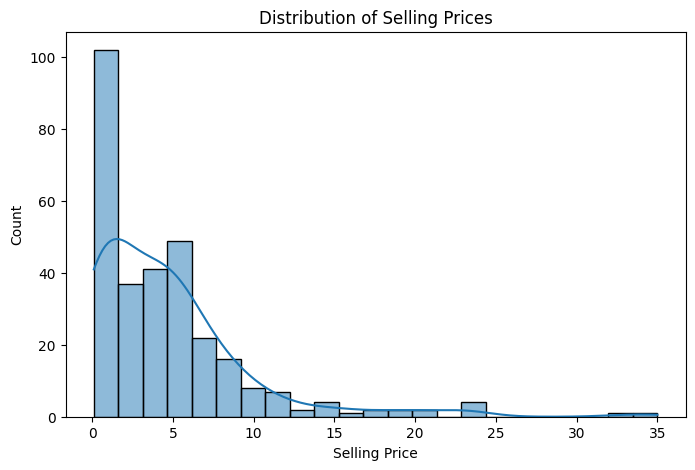

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Selling_Price'], kde=True)

plt.title("Distribution of Selling Prices")
plt.xlabel("Selling Price")
plt.show()

In [ ]:
# Transform categorical columns into numerical form

df = pd.get_dummies(
    df,
    columns=['Fuel_Type', 'Selling_type', 'Transmission'],
    drop_first=True
)

df.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,11,False,True,False,True
1,4.75,9.54,43000,0,12,True,False,False,True
2,7.25,9.85,6900,0,8,False,True,False,True
3,2.85,4.15,5200,0,14,False,True,False,True
4,4.60,6.87,42450,0,11,True,False,False,True


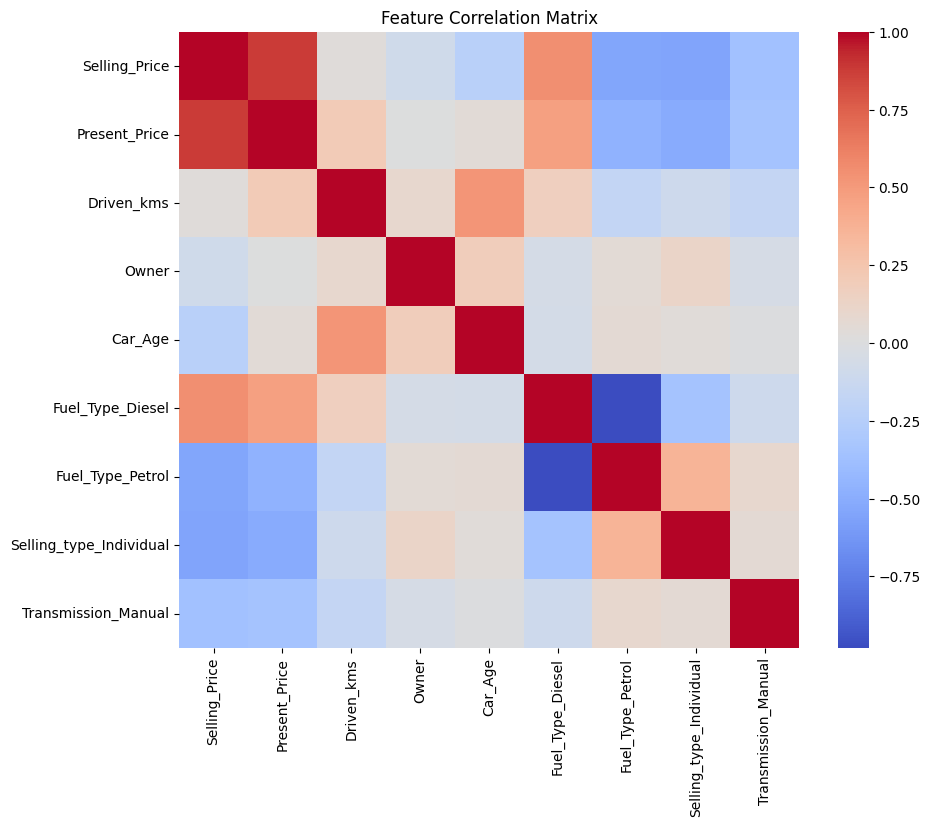

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=False, cmap='coolwarm')

plt.title("Feature Correlation Matrix")

plt.show()

In [ ]:
# Input features

X = df.drop('Selling_Price', axis=1)

# Output variable

y = df['Selling_Price']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 240
Testing Samples: 61


In [ ]:
# Train Linear Regression Model

from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [ ]:
predictions = lr_model.predict(X_test)

predictions[:5]

array([ 2.95433731,  8.17716341,  6.45612271, -1.42337164,  9.08864657])

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("MSE :", mse)
print("R² Score :", r2)

MAE : 1.2163740193330348
MSE : 3.4813498305118165
R² Score : 0.8488707839193155


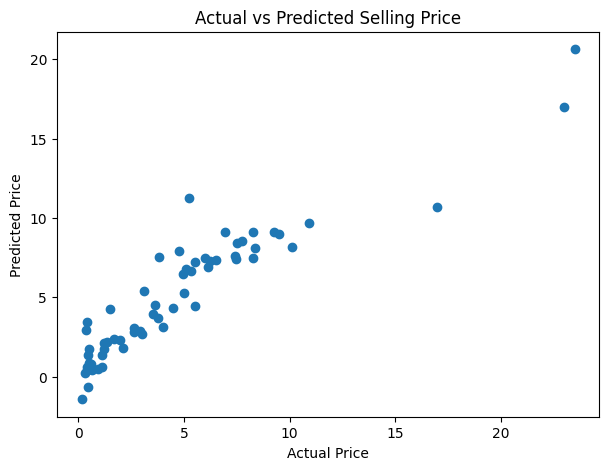

In [ ]:
# Compare Actual vs Predicted Values
plt.figure(figsize=(7,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Selling Price")

plt.show()

In [ ]:
# Save Model
import joblib

joblib.dump(lr_model, "car_price_prediction_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [ ]:
# Train a Random Forest Model

from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Generate predictions
rf_predictions = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

rf_r2 = r2_score(y_test, rf_predictions)
rf_mae = mean_absolute_error(y_test, rf_predictions)

print("Random Forest Results")
print("---------------------")
print("MAE :", rf_mae)
print("R² Score :", rf_r2)

Random Forest Results
---------------------
MAE : 0.6368655737704919
R² Score : 0.9594566919773236


In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,Present_Price,0.881166
3,Car_Age,0.059495
1,Driven_kms,0.040265
7,Transmission_Manual,0.009646
4,Fuel_Type_Diesel,0.004339
5,Fuel_Type_Petrol,0.002564
6,Selling_type_Individual,0.002155
2,Owner,0.000370


In [ ]:
import joblib

joblib.dump(rf_model, "car_price_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!
